In [ ]:
#Constants

from datetime import datetime
import numpy as np

DB_PATH = "database/train.sqlite"
CHUNK_SIZE = 1_000_000
QUERY = """
    SELECT *
    FROM tripdata
    WHERE trip_distance between 0.01 and 5
    and fare_amount between 0 and 60
    and vendorid between 1 and 2
    and fare_amount between 0 and 25
    and extra between 0 and 1
    and tip_amount between 0.01 and 5
    and tolls_amount between 0 and 50
    and total_amount between 0 and 40
    and payment_type between 1 and 6
    LIMIT 10000000
"""

columns = [
    "vendorid",
    #"tpep_pickup_datetime",
    #"tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    #"ratecodeid",
    #"store_and_fwd_flag",
    "pulocationid",
    "dolocationid",
    #"payment_type",
    "fare_amount",
    "extra",
    #"mta_tax",
    "tip_amount",
    #"tolls_amount",
    #"improvement_surcharge",
    "total_amount",
    #"congestion_surcharge"
]

date_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
]

stats = {
    col: {"min": np.inf, "max": -np.inf}
    for col in columns
}

date_stats = {
    col: {"min": datetime.max, "max": datetime.min}
    for col in date_cols
}

In [2]:
# First pass to determine bin sizes
from datetime import datetime
import pandas as pd
import numpy as np
import sqlite3
import json

DATE_FORMAT = "%Y-%m-%d %H:%M:%S.%f"

PARSE_DATE_DICT = {
    "tpep_pickup_datetime":DATE_FORMAT,
    "tpep_dropoff_datetime":DATE_FORMAT
}

class DateTimeEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, datetime):
            return obj.isoformat()
        return super().default(obj)

conn = sqlite3.connect(DB_PATH)

for chunk in pd.read_sql_query(QUERY, conn, chunksize=CHUNK_SIZE, parse_dates=PARSE_DATE_DICT):
    for col in date_cols:
        values = chunk[col].dropna()

        if not values.empty:
            date_stats[col]["min"] = min(date_stats[col]["min"], values.min())
            date_stats[col]["max"] = max(date_stats[col]["max"], values.max())

    for col in columns:
        values = chunk[col].dropna()

        if not values.empty:
            stats[col]["min"] = min(stats[col]["min"], values.min())
            stats[col]["max"] = max(stats[col]["max"], values.max())

conn.close()

with open("column_stats.json", "w") as f:
    json.dump(stats, f, indent=4)

with open("column_date_stats.json", "w") as f:
    json.dump(date_stats, f, cls=DateTimeEncoder, indent=4)

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import json

with open("column_stats.json") as f:
    stats = json.load(f)

with open("column_date_stats.json") as f:
    date_stats = json.load(f)

bins = {
    col: np.linspace(
        stats[col]["min"],
        stats[col]["max"],
        50
    )
    for col in stats
}

histograms = {
    col: np.zeros(len(bins[col]) - 1)
    for col in bins
}

conn = sqlite3.connect(DB_PATH)

for chunk in pd.read_sql_query(QUERY, conn, chunksize=CHUNK_SIZE):
    for col in columns:
        counts, _ = np.histogram(
            chunk[col].dropna(),
            bins=bins[col]
        )
        histograms[col] += counts

conn.close()

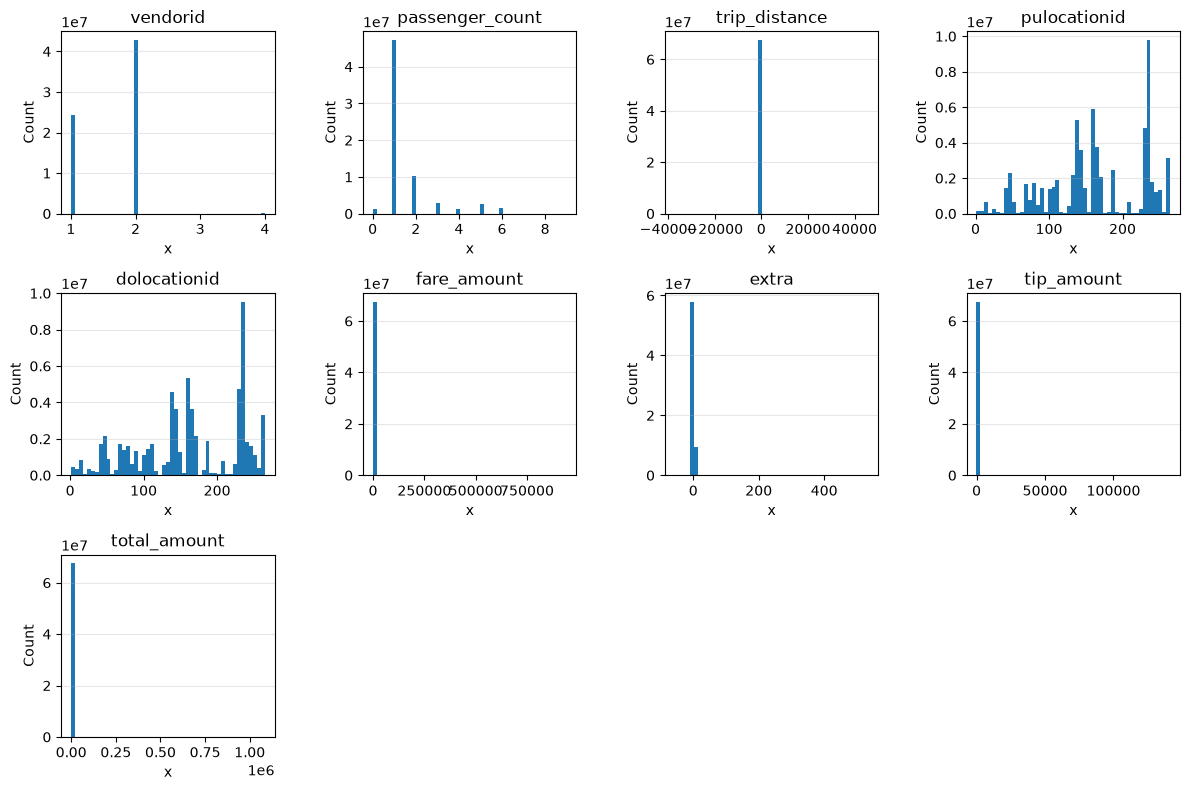

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np

n = len(columns) # + len(date_cols)
ncols = 4
nrows = math.ceil(n / ncols)

plt.figure(figsize=(12,8))
for i, col in enumerate(columns):
    plt.subplot(nrows, ncols, i + 1)

    plt.bar(
        bins[col][:-1],
        histograms[col],
        width=np.diff(bins[col]),
        align="edge"
    )

    plt.title(col)
    plt.xlabel("x")
    plt.ylabel("Count")
    plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
